In [ ]:
from datasets import load_dataset

ds = load_dataset("weathon/critical_comp")

In [ ]:
# !pip install hpsv2x -qq

In [ ]:
# !pip install hpsv3

In [ ]:
from hpsv3 import HPSv3RewardInferencer

# Initialize the model
inferencer = HPSv3RewardInferencer(device='cuda')

Flash Attention is not installed. Falling to SDPA.


`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Some weights of Qwen2VLRewardModelBT were not initialized from the model checkpoint at Qwen/Qwen2-VL-7B-Instruct and are newly initialized: ['rm_head.0.bias', 'rm_head.0.weight', 'rm_head.3.bias', 'rm_head.3.weight', 'rm_head.5.bias', 'rm_head.5.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import numpy as np
from PIL import Image
def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [ ]:
import torch
from diffusers import FluxPipeline

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-Krea-dev", torch_dtype=torch.bfloat16)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [ ]:
pipe = pipe.to("cuda")

In [ ]:
ds = ds["train"]
ds

Dataset({
    features: ['topic', 'model', 'prompts'],
    num_rows: 50
})

In [ ]:
import diffusers
diffusers.utils.logging.disable_progress_bar()

In [ ]:
import wandb

In [ ]:
wandb.init()

wandb: Currently logged in as: wguo6358 (3dsmile) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# ds = ds['train']

In [ ]:
import tqdm
import torch

def generate_image(sample, idx):
  if len(sample["prompts"]["soft_prompt"])<10 or len(sample["prompts"]["critical_prompt"])<10:
    return sample

  prompt = sample["prompts"]["soft_prompt"]
  soft_image = pipe(
      prompt,
      height=1024,
      width=1024,
      guidance_scale=4.5,
      generator=torch.Generator("cuda").manual_seed(idx),
      num_inference_steps=28
  ).images[0]

  prompt = sample["prompts"]["critical_prompt"]
  critical_image = pipe(
      prompt,
      height=1024,
      width=1024,
      guidance_scale=4.5,
      generator=torch.Generator("cuda").manual_seed(idx),
      num_inference_steps=28
  ).images[0]

  prompt = sample["prompts"]["critical_prompt"]
  image_paths = [soft_image, critical_image]
  prompts = [prompt] * 2
  with torch.no_grad():
    rewards = inferencer.reward(prompts=prompts, image_paths=image_paths)
    scores = [reward[0].item() for reward in rewards]  # Extract mu values
    print(f"Image scores: {scores}")
  sample["hpsv3"] = scores
  sample["soft_image"] = soft_image
  sample["critical_image"] = critical_image
  wandb.log({
      "image": wandb.Image(hstack([soft_image, critical_image]), caption=str(scores)),
      "step": idx
  })
  return sample

In [ ]:
new_ds = []
for idx, sample in enumerate(tqdm.tqdm(ds)):
  new_ds.append(generate_image(sample, idx))

In [ ]:
from datasets import Dataset
ds = Dataset.from_list(new_ds)
ds.push_to_hub("weathon/critical_comp")

In [ ]:
# import hpsv2

# result = hpsv2.score([soft_image, critical_image], prompt, hps_version="v2.1")
# result

In [ ]:
# soft_image.save("soft.png")
# critical_image.save("critical.png")

In [ ]:
# image_1 = Image.open("Gemini_Generated_Image_5n1x9y5n1x9y5n1x.png")
# image_2 = Image.open("Gemini_Generated_Image_85fliw85fliw85fl.png")
paths = "/Users/wenqiguo/Downloads/Gemini_Generated_Image_k0eu5ck0eu5ck0eu.png /Users/wenqiguo/Downloads/Gemini_Generated_Image_cgu1hvcgu1hvcgu1.png".split(" ")
# paths = ["/Users/wenqiguo/Downloads/Screenshot 2025-11-06 at 22.12.02.png", "/Users/wenqiguo/Downloads/Screenshot 2025-11-06 at 22.12.22.png"]

image_1 = Image.open(paths[0].replace("/Users/wenqiguo/Downloads/", ""))
image_2 = Image.open(paths[1].replace("/Users/wenqiguo/Downloads/", ""))

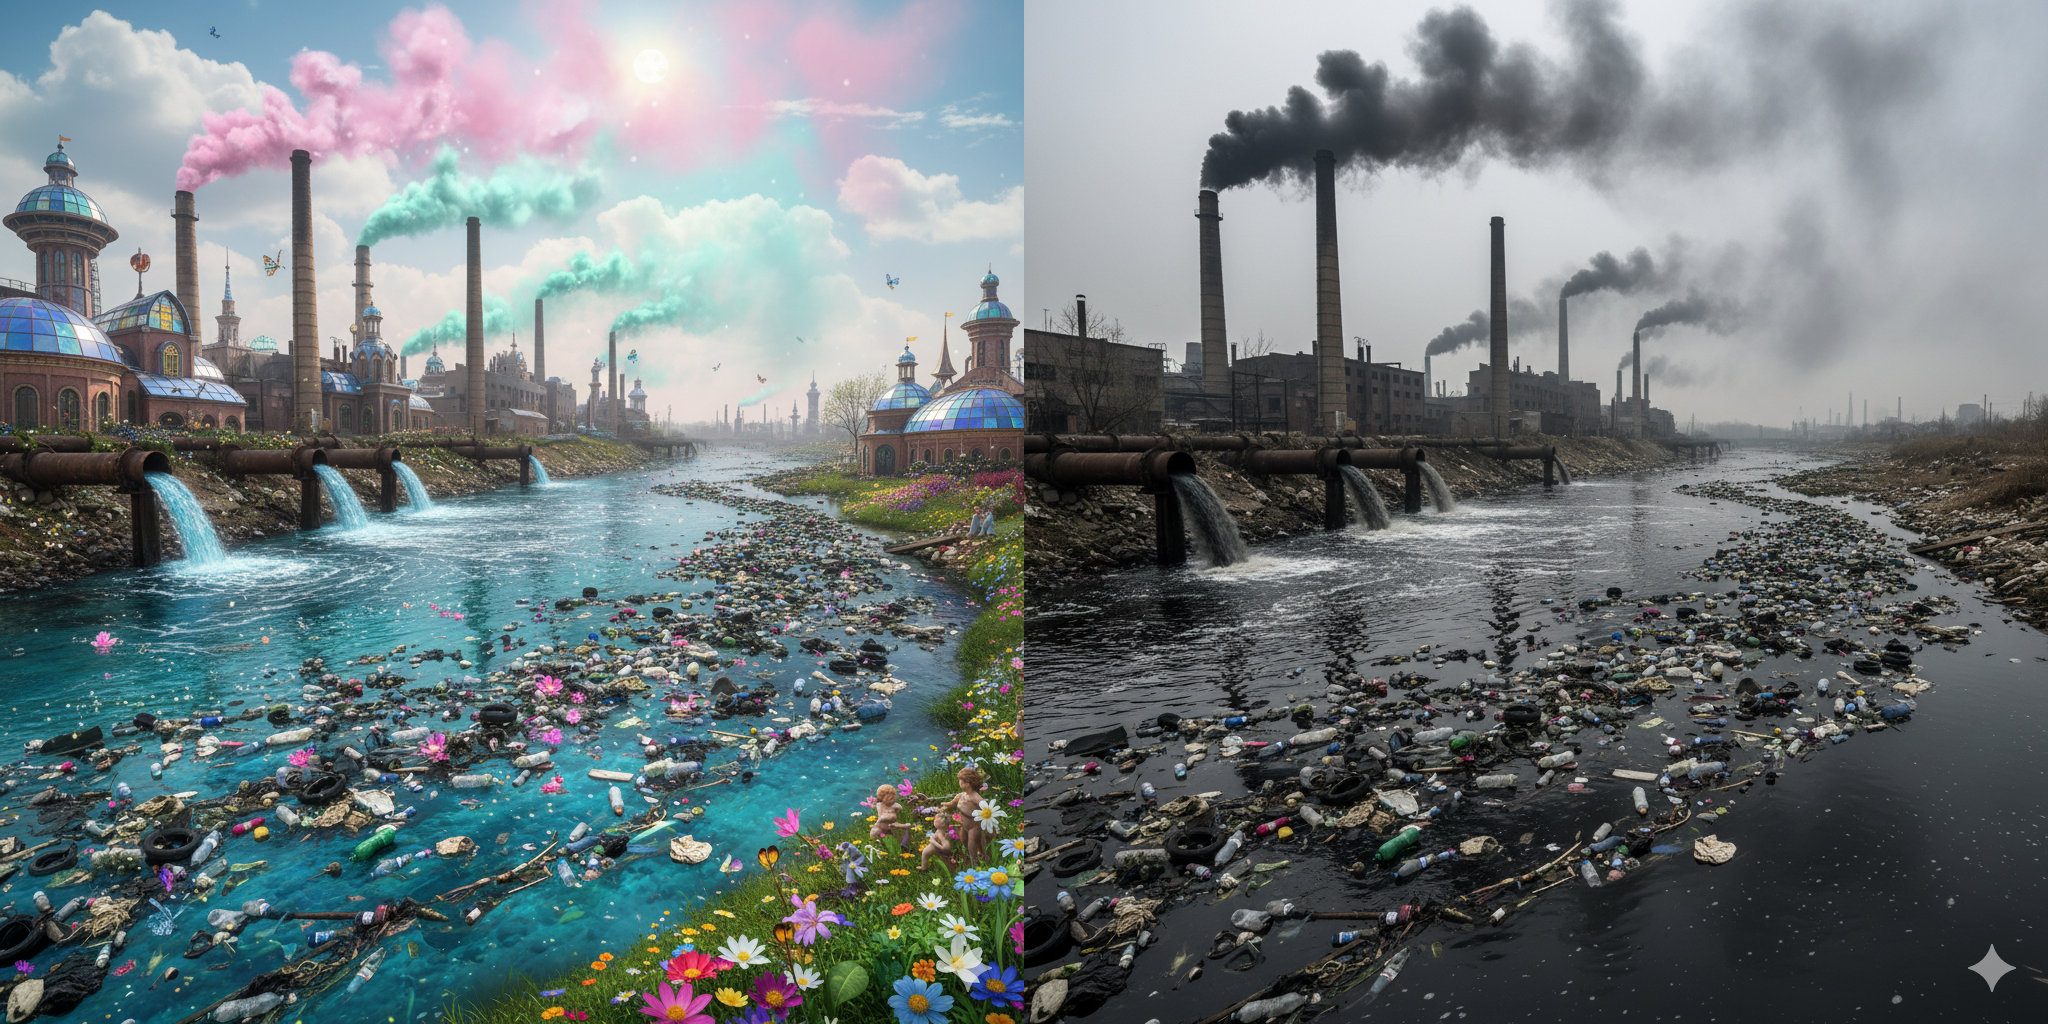

In [ ]:
hstack([image_1, image_2])

In [ ]:

prompt = "A river with trash floating on it. The water has a dark color. There are factories next to the river with high chimneys releasing dark smoke and pipes releasing wastewater into the river."
image_paths = [image_1, image_2]
prompts = [prompt] * 2
with torch.no_grad():
  rewards = inferencer.reward(prompts=prompts, image_paths=image_paths)
  scores = [reward[0].item() for reward in rewards]  # Extract mu values
  print(f"Image scores: {scores}")

Image scores: [11.167695045471191, 12.942529678344727]
